# Comparing Linear Regression models

In [2]:
#import modules and data
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('housing.csv', sep = ',', header =None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
df.shape
df.columns = ['CRIM','ZN','INDUS', 'CHAS' , 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT' , 'MEDV' ]
print(df.head())
data = df.values

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [4]:
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


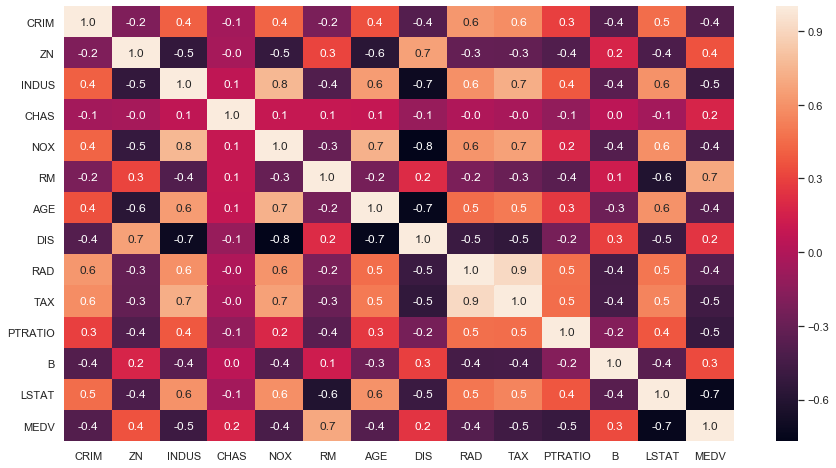

In [5]:
# using the correlation matrix you can choose the variables that highly correlated with our target variable
sns.set(rc = {'figure.figsize':(15,8)})
sns.heatmap(df.corr(), annot = True, fmt = ".1f")
plt.show()

In [6]:
#column_name=['INDUS','RM','TAX','PTRATIO','LSTAT']
#X, y = df[column_name], df['MEDV'] 
x, y = data[:,:-1], data[:,-1] 

## Prediction with Linear Regression 

In [7]:
from sklearn.model_selection import train_test_split #Split arrays or matrices into
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=0)
model1 = LinearRegression()
model1.fit(X_train, y_train)
y_1 = model1.predict(X_test)
print("R^2: ", r2_score(y_test,y_1))
print("MSE:", mean_squared_error(y_1,y_test))
#print(y_1)

R^2:  0.635463843320215
MSE: 29.782245092302194


In [9]:
from sklearn.model_selection import cross_val_score
cv_1= cross_val_score(model1,x,y, cv = 10)
print(cv_1)
cv_1 = np.absolute(cv_1)
print('Mean MAE: %.3f (%.3f)' % (np.mean(cv_1), np.std(cv_1)))

[ 0.73376082  0.4730725  -1.00631454  0.64113984  0.54766046  0.73640292
  0.37828386 -0.12922703 -0.76843243  0.4189435 ]
Mean MAE: 0.583 (0.235)


## Prediction with Ridge Regression

In [21]:
from sklearn.linear_model import Ridge
model2 = Ridge(alpha=0.08)
model2.fit(X_train, y_train)
y_2 = model2.predict(X_test)
print("R^2: ", r2_score(y_test,y_2))
print("MSE:", mean_squared_error(y_2,y_test))
#print(y_2)

R^2:  0.6345171556955154
MSE: 29.85958853916752


In [19]:
# First Way
cv_2= cross_val_score(model2,x,y, cv = 10)
cv_2 = np.absolute(cv_2)
print(cv_2)
print('Mean MAE: %.3f (%.3f)' % (np.mean(cv_2), np.std(cv_2)))


#Second Way
from sklearn.model_selection import KFold
cv = KFold(n_splits=10, random_state=1)
# evaluate model
scores = cross_val_score(model2, x, y, cv=cv)
print(scores)
# force scores to be positive
scores = np.absolute(scores)
print('Mean MAE: %.3f (%.3f)' % (np.mean(scores), np.std(scores)))

[0.73288024 0.53053457 0.53943322 0.62684493 0.57977914 0.75248112
 0.40833757 0.13005149 0.79325061 0.39354646]
Mean MAE: 0.549 (0.190)
[ 0.73288024  0.53053457 -0.53943322  0.62684493  0.57977914  0.75248112
  0.40833757 -0.13005149 -0.79325061  0.39354646]
Mean MAE: 0.549 (0.190)


## Prediction with Lasso Regression

In [20]:
from sklearn.linear_model import Lasso
model3 = Lasso(alpha=1)
model3.fit(X_train, y_train)
y_3 = model3.predict(X_test)
print("R^2: ", r2_score(y_test,y_3))
print("MSE:", mean_squared_error(y_3,y_test))
#print(y_3)

R^2:  0.5516247059049908
MSE: 36.63182007429978


In [23]:
cv_3= cross_val_score(model3,X,y, cv = 10)
cv_3 = np.absolute(cv_3)
print('Mean MAE: %.3f (%.3f)' % (np.mean(cv_3), np.std(cv_3)))

Mean MAE: 0.357 (0.151)


### Choosing lambda

In [24]:
grid = dict()
grid['alpha'] = np.arange(0, 1, 0.01)
print(grid)

{'alpha': array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])}


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
model = Ridge()
# define model evaluation method
cv = KFold(n_splits=10, random_state=1, shuffle=True)
# define grid
grid = dict()
grid['alpha'] = np.arange(0, 1, 0.01)
# define search
search = GridSearchCV(model, grid, cv=cv, n_jobs=-1)
# perform the search
results = search.fit(X, y)
# summarize
print('MAE: %.3f' % results.best_score_)
print('Config: %s' % results.best_params_)

MAE: 0.719
Config: {'alpha': 0.08}


C:\Users\Gaukhara\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:813: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


# Exercise

### Generate data from a linear model with controllable noise and number of features.

Use the Diabetes dataset from scikit-learn:

In [14]:
from sklearn.datasets import load_diabetes
X, y = load_diabetes(return_X_y=True)

### Task 1 — Data preparation
- Load the dataset and split into training and test sets (train_test_split, 80/20 split).
- Standardize features (mean=0, variance=1) using StandardScaler.

### Task 2 — Baseline model
- Fit an Ordinary Least Squares (LinearRegression) model.
- Record training and test RMSE and R^2.
- Save coefficients for comparison.

### Task 3 — Ridge regression
- Train Ridge regression with a grid of alpha values (e.g., [0.01, 0.1, 1, 10, 100]).
- Plot training and test RMSE vs log(alpha) to visualize the bias–variance tradeoff.
- Compare Ridge coefficients to OLS.
- Plot Ridge coefficient paths as alpha varies (use sklearn.linear_model.Ridge with alphas grid).

### Task 4 — Lasso regression
- Train Lasso regression with the same grid of alpha values.
- Plot training and test RMSE vs log(alpha).
- Plot the number of non-zero coefficients vs alpha.
- Plot Lasso coefficient paths across a fine grid of alphas.

### Task 5 — Cross-validation
- Use GridSearchCV with 10-fold CV to select the best alpha for Ridge and Lasso.
- Report selected alpha values and corresponding RMSE on the test set.

### Task 6 — Bias–Variance tradeoff (extended)
- Perform repeated train/test splits (e.g., 30 repetitions).
- For each alpha, compute average training RMSE, test RMSE, and their variances.
- Plot curves showing how training error, test error, and variance change with log(alpha).
- Discuss where bias dominates and where variance dominates.